# 02 — Baseline TF-IDF + Logistic Regression
## Aoranema Sentiment Analysis

Notebook ini membangun **baseline model** untuk klasifikasi sentimen Aoranema menggunakan:

- **TF-IDF** untuk mengubah teks menjadi fitur numerik.
- **Logistic Regression** untuk mengklasifikasikan sentimen.

Target kelas:

- `positive`
- `neutral`
- `negative`

Dataset input:

`sentiment_clean.csv`

Dataset ini merupakan output dari:

`01_data_audit_eda.ipynb`

---

## Tujuan Notebook

Pada notebook ini kita akan:

1. Memuat dataset bersih.
2. Membagi data menjadi **train / validation / test** secara stratified.
3. Membuat pipeline TF-IDF + Logistic Regression.
4. Melatih baseline model.
5. Mengevaluasi pada validation set.
6. Mengevaluasi final pada test set.
7. Melihat confusion matrix dan classification report.
8. Melakukan error analysis sederhana.
9. Mencoba prediksi manual.
10. Menyimpan model baseline dan hasil evaluasi.

> **Catatan:** test set hanya dipakai untuk evaluasi akhir dan tidak digunakan untuk training.

## 1. Import Library

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42

print("Pandas       :", pd.__version__)
print("NumPy        :", np.__version__)

Pandas       : 2.3.3
NumPy        : 2.0.2


## 2. Mencari `sentiment_clean.csv`

Notebook akan mencoba mencari dataset bersih di:

1. `/kaggle/input`
2. `/kaggle/working`

Jika notebook ini dijalankan sebagai notebook Kaggle terpisah, biasanya file output notebook sebelumnya perlu:

- disimpan sebagai Kaggle Output/Dataset,
- lalu ditambahkan melalui **Add Input**.

In [2]:
FILE_NAME = "sentiment_clean.csv"

search_locations = [
    Path("/kaggle/input"),
    Path("/kaggle/working")
]

matches = []

for location in search_locations:
    if location.exists():
        matches.extend(location.rglob(FILE_NAME))

if not matches:
    raise FileNotFoundError(
        f"{FILE_NAME} tidak ditemukan.\n"
        "Pastikan output dari Notebook 01 sudah ditambahkan sebagai input Kaggle "
        "atau tersedia di /kaggle/working."
    )

DATA_PATH = matches[0]

print("Dataset ditemukan:")
print(DATA_PATH)

if len(matches) > 1:
    print("\nDitemukan lebih dari satu file:")
    for i, path in enumerate(matches, start=1):
        print(f"{i}. {path}")
    print("\nNotebook menggunakan file pertama.")

Dataset ditemukan:
/kaggle/input/datasets/onallaaldeanuva/sentiment-clean-csv/sentiment_clean.csv


## 3. Load Dataset

In [3]:
df = pd.read_csv(DATA_PATH)

print("Shape dataset:", df.shape)
print("Kolom:", df.columns.tolist())

display(df.head())

Shape dataset: (21589, 2)
Kolom: ['content', 'sentiment']


,content,sentiment
0,bukan menyenangkan malah bikin kesal hp saya realme c 11 malah ngeblank hitam ga masuk keloading giliran udah masuk malah loading nya berhenti masuk juga mod nya kadang muncul ...,negative
1,"kalo ngak niat bikin gamenya bagus hapus aja dah gamenya, masa setiap narik atau mabar diconet mulu, kalo niat bikin game update ada apa saja bug pada game, kalo udah bener nta...",negative
2,"kntl, masa ada iklan ngga bisa di skip. Padahal perjalanan kurang 1 kota lagi. Jadi males main online, udah gitu mobil yang dari lawan arah tiba"" menabrak bis saya..terus juga ...",negative
3,"makin lama, makin gak jelas dri sblum di update game ini tiba tiba keluar sndiri tapi setelah di update 3.7 suka keluar sndiri di saat mau main, mana bnyak Bug tlong di perbaik...",negative
4,semenjak update sangat sangat buruk setiap main bareng sering disconeted padahal sinyal bagus cukup bintang satu aja untuk,negative


## 4. Validasi Dataset

Kita memastikan bahwa dataset memiliki:

- kolom `content`,
- kolom `sentiment`,
- tidak ada missing value,
- hanya tiga label target.

In [4]:
required_columns = {"content", "sentiment"}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"Kolom wajib tidak ditemukan: {missing_columns}"
    )

valid_labels = {"positive", "neutral", "negative"}

assert df["content"].notna().all(), "Masih ada content yang kosong."
assert df["sentiment"].notna().all(), "Masih ada sentiment yang kosong."
assert set(df["sentiment"].unique()).issubset(valid_labels), \
    "Ditemukan label sentiment yang tidak valid."

print("Validasi dataset berhasil.")

Validasi dataset berhasil.


## 5. Distribusi Kelas

Walaupun sudah dicek pada Notebook 01, kita cek kembali untuk memastikan data yang digunakan sama.

In [5]:
class_counts = (
    df["sentiment"]
    .value_counts()
    .reindex(["negative", "neutral", "positive"])
)

class_percent = (
    class_counts / class_counts.sum() * 100
).round(2)

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percent": class_percent
})

display(class_distribution)

,count,percent
sentiment,,
negative,7716,35.74
neutral,7423,34.38
positive,6450,29.88


## 6. Menentukan Fitur dan Target

- `X` = teks review / feedback.
- `y` = label sentiment.

In [6]:
X = df["content"].astype(str)
y = df["sentiment"].astype(str)

print("Jumlah data:", len(X))
print("Jumlah kelas:", y.nunique())

Jumlah data: 21589
Jumlah kelas: 3


## 7. Train / Validation / Test Split

Kita menggunakan pembagian:

- **80% Train**
- **10% Validation**
- **10% Test**

Karena kita menggunakan **stratified split**, proporsi `positive`, `neutral`, dan `negative` tetap relatif sama pada setiap bagian.

Alurnya:

```text
100% Dataset
    ↓
80% Train
20% Temporary
    ↓
10% Validation
10% Test
```

In [7]:
# Split pertama: 80% train, 20% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split kedua: 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))

print("\nTotal:", len(X_train) + len(X_val) + len(X_test))

Train      : 17271
Validation : 2159
Test       : 2159

Total: 21589


## 8. Memeriksa Distribusi Kelas Setelah Split

Tujuannya memastikan stratification bekerja dengan benar.

In [8]:
def distribution_table(series, name):
    counts = (
        series.value_counts()
        .reindex(["negative", "neutral", "positive"])
    )

    percent = (counts / counts.sum() * 100).round(2)

    result = pd.DataFrame({
        f"{name}_count": counts,
        f"{name}_percent": percent
    })

    return result


split_distribution = pd.concat([
    distribution_table(y_train, "train"),
    distribution_table(y_val, "validation"),
    distribution_table(y_test, "test")
], axis=1)

display(split_distribution)

,train_count,train_percent,validation_count,validation_percent,test_count,test_percent
sentiment,,,,,,
negative,6173,35.74,771,35.71,772,35.76
neutral,5938,34.38,743,34.41,742,34.37
positive,5160,29.88,645,29.87,645,29.87


## 9. Kenapa TF-IDF?

Komputer tidak bisa langsung memahami teks mentah.

TF-IDF mengubah kata menjadi angka berdasarkan:

- seberapa sering kata muncul pada sebuah dokumen,
- seberapa unik kata tersebut dibanding dokumen lain.

Contoh sederhana:

```text
"aplikasinya bagus"
"aplikasinya lambat"
```

TF-IDF akan menghasilkan representasi numerik sehingga Logistic Regression dapat mempelajari pola kata yang sering berhubungan dengan sentimen tertentu.

---

## 10. Membuat Baseline Pipeline

Kita menggunakan:

### TF-IDF

Beberapa parameter penting:

- `ngram_range=(1, 2)`  
  Menggunakan unigram dan bigram.

  Contoh unigram:
  ```text
  bagus
  ```

  Contoh bigram:
  ```text
  sangat bagus
  ```

- `min_df=2`  
  Kata harus muncul minimal di 2 dokumen.

- `max_df=0.95`  
  Kata yang muncul pada lebih dari 95% dokumen akan diabaikan.

- `sublinear_tf=True`  
  Mengurangi dominasi kata yang terlalu sering muncul.

### Logistic Regression

Model klasifikasi linear yang cocok sebagai baseline untuk teks TF-IDF.

In [9]:
baseline_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            max_features=100_000
        )
    ),
    (
        "logreg",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

baseline_pipeline

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=100000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('logreg', LogisticRegression(max_iter=1000, random_state=42))])

## 11. Training Baseline Model

Pipeline akan:

```text
Text
 ↓
TF-IDF
 ↓
Logistic Regression
```

TF-IDF hanya akan **fit pada train set**, sehingga validation dan test tidak bocor ke proses training.

In [10]:
baseline_pipeline.fit(X_train, y_train)

print("Training selesai.")

Training selesai.


## 12. Informasi TF-IDF

Kita dapat melihat jumlah fitur/kata yang dipelajari dari train set.

In [11]:
tfidf_model = baseline_pipeline.named_steps["tfidf"]

feature_names = tfidf_model.get_feature_names_out()

print("Jumlah fitur TF-IDF:", len(feature_names))

print("\nContoh 30 fitur pertama:")
print(feature_names[:30])

Jumlah fitur TF-IDF: 32503

Contoh 30 fitur pertama:
['00' '00 00' '00 pas' '00 tapi' '00 tolong' '00 yg' '01' '02' '02 2020'
 '06' '09' '10' '10 00' '10 angka' '10 detik' '10 jam' '10 jt' '10 juta'
 '10 malem' '10 menit' '10 pagi' '10 rb' '10 ribu' '100' '100 00'
 '100 200' '100 dan' '100 ga' '100 kontak' '100 lebih']


## 13. Fungsi Evaluasi

Agar evaluasi validation dan test konsisten, kita membuat satu fungsi.

Metric utama:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1

### Kenapa Macro F1?

Macro F1 menghitung F1 setiap kelas lalu mengambil rata-ratanya.

Dengan begitu:

```text
positive
neutral
negative
```

memiliki bobot yang sama dalam evaluasi.

In [12]:
LABEL_ORDER = ["negative", "neutral", "positive"]


def evaluate_model(model, X_data, y_true, dataset_name="Dataset"):
    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0
    )

    metrics = {
        "accuracy": float(accuracy),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1)
    }

    print(f"=== {dataset_name.upper()} METRICS ===")
    for key, value in metrics.items():
        print(f"{key:16s}: {value:.4f}")

    return metrics, y_pred

## 14. Evaluasi pada Validation Set

Validation set digunakan untuk melihat performa model sebelum menyentuh test set.

In [13]:
val_metrics, y_val_pred = evaluate_model(
    baseline_pipeline,
    X_val,
    y_val,
    dataset_name="Validation"
)

=== VALIDATION METRICS ===
accuracy        : 0.7726
macro_precision : 0.7734
macro_recall    : 0.7726
macro_f1        : 0.7729


## 15. Classification Report — Validation

In [14]:
print(
    classification_report(
        y_val,
        y_val_pred,
        labels=LABEL_ORDER,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.8076    0.8275    0.8174       771
     neutral     0.7064    0.7026    0.7045       743
    positive     0.8063    0.7876    0.7969       645

    accuracy                         0.7726      2159
   macro avg     0.7734    0.7726    0.7729      2159
weighted avg     0.7724    0.7726    0.7724      2159



## 16. Confusion Matrix — Validation

Confusion matrix membantu melihat kelas mana yang sering tertukar.

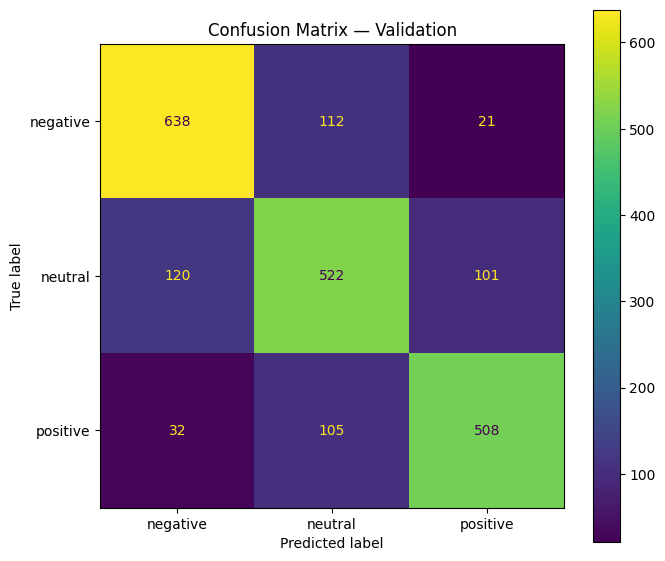

In [15]:
cm_val = confusion_matrix(
    y_val,
    y_val_pred,
    labels=LABEL_ORDER
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=LABEL_ORDER
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("Confusion Matrix — Validation")

plt.tight_layout()
plt.show()

# 17. Evaluasi Final pada Test Set

Setelah model baseline selesai diperiksa melalui validation set, sekarang kita melakukan **evaluasi final pada test set**.

Test set sebelumnya tidak digunakan dalam training maupun pemilihan parameter.

In [16]:
test_metrics, y_test_pred = evaluate_model(
    baseline_pipeline,
    X_test,
    y_test,
    dataset_name="Test"
)

=== TEST METRICS ===
accuracy        : 0.7781
macro_precision : 0.7809
macro_recall    : 0.7767
macro_f1        : 0.7783


## 18. Classification Report — Test

In [17]:
test_report = classification_report(
    y_test,
    y_test_pred,
    labels=LABEL_ORDER,
    digits=4,
    zero_division=0,
    output_dict=True
)

display(
    pd.DataFrame(test_report).transpose()
)

,precision,recall,f1-score,support
negative,0.811083,0.834197,0.822478,772.000000
neutral,0.710183,0.733154,0.721485,742.000000
positive,0.821369,0.762791,0.790997,645.000000
accuracy,0.778138,0.778138,0.778138,0.778138
macro avg,0.780878,0.776714,0.778320,2159.000000
weighted avg,0.779479,0.778138,0.778364,2159.000000


## 19. Confusion Matrix — Test

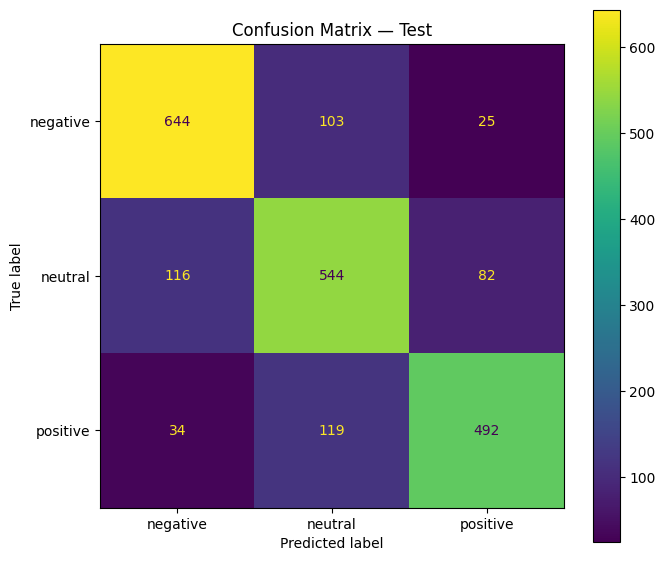

In [18]:
cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    labels=LABEL_ORDER
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=LABEL_ORDER
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("Confusion Matrix — Test")

plt.tight_layout()
plt.show()

## 20. Menambahkan Confidence Score

Logistic Regression dapat memberikan probabilitas prediksi untuk setiap kelas.

Contoh:

```text
negative : 0.82
neutral  : 0.11
positive : 0.07
```

Confidence diambil dari probabilitas kelas yang dipilih model.

In [19]:
test_probabilities = baseline_pipeline.predict_proba(X_test)

classes = baseline_pipeline.classes_

confidence = test_probabilities.max(axis=1)

prediction_df = pd.DataFrame({
    "content": X_test.values,
    "actual": y_test.values,
    "predicted": y_test_pred,
    "confidence": confidence
})

display(prediction_df.head())

,content,actual,predicted,confidence
0,sangat2 memuaskan bagi kami,positive,positive,0.710818
1,Aplikasinya bagus banget cuma pada saat mabar sering ngelag.. Tiba tinggal sendirian padahal masih di lokasi yg sama.. tolong di perbaiki,negative,negative,0.834769
2,Bagus permainannya seru tetapi menantang,positive,positive,0.792670
3,Tolong benerin nih bug keluar sendiri pas mau main kalo keluar terus gimana mainnya,neutral,negative,0.805552
4,Ini pinjaman bisa dicicil atau tidak,neutral,negative,0.598585


## 21. Error Analysis

Kita melihat beberapa contoh prediksi yang salah.

Tujuannya bukan hanya mencari nilai metric, tetapi memahami **jenis kesalahan model**.

In [20]:
errors = prediction_df[
    prediction_df["actual"] != prediction_df["predicted"]
].copy()

errors = errors.sort_values(
    "confidence",
    ascending=False
)

print("Jumlah prediksi salah:", len(errors))
print(
    "Persentase error:",
    f"{len(errors) / len(prediction_df) * 100:.2f}%"
)

display(errors.head(20))

Jumlah prediksi salah: 479
Persentase error: 22.19%


,content,actual,predicted,confidence
985,Endah bagus,negative,positive,0.998564
1137,Bmudahmufahan bagus,neutral,positive,0.998564
143,Myan bagus,neutral,positive,0.998564
1843,Ru coba,positive,neutral,0.978264
429,Gimana sih caranya verifikasi akun? Padahal sudah masuk kode verifikasinya tapi kok failed terus?,neutral,negative,0.961102
691,Saya susah masuknya kenapa yah? Pas ngisi email dll kok gak bisa masuk,neutral,negative,0.957709
1863,Lengkap dan sangat membantu,neutral,positive,0.956505
1109,Game nya gw suka tapi masih banyak bug semacam masuk ke game malah layar hitam terus lalu bug kedua tiba tiba stuck sendiri seperti mau mulai game saat udh masuk malah stuck di...,neutral,negative,0.951511
27,Kasi bintang 1 dulu Soal nya baru mencoba,negative,neutral,0.939982
1762,kurang tespon,neutral,negative,0.937935


### Prediksi salah dengan confidence tinggi

Kasus seperti ini menarik karena model sangat yakin, tetapi label aktual berbeda.

Kemungkinan penyebab dapat berupa:

- bahasa ambigu,
- ironi/sarkasme,
- teks mengandung lebih dari satu sentimen,
- label dataset yang tidak mudah dibedakan,
- keterbatasan model berbasis TF-IDF.

In [21]:
high_conf_errors = errors[
    errors["confidence"] >= 0.80
]

print("Error dengan confidence >= 0.80:", len(high_conf_errors))

display(high_conf_errors.head(20))

Error dengan confidence >= 0.80: 52


,content,actual,predicted,confidence
985,Endah bagus,negative,positive,0.998564
1137,Bmudahmufahan bagus,neutral,positive,0.998564
143,Myan bagus,neutral,positive,0.998564
1843,Ru coba,positive,neutral,0.978264
429,Gimana sih caranya verifikasi akun? Padahal sudah masuk kode verifikasinya tapi kok failed terus?,neutral,negative,0.961102
691,Saya susah masuknya kenapa yah? Pas ngisi email dll kok gak bisa masuk,neutral,negative,0.957709
1863,Lengkap dan sangat membantu,neutral,positive,0.956505
1109,Game nya gw suka tapi masih banyak bug semacam masuk ke game malah layar hitam terus lalu bug kedua tiba tiba stuck sendiri seperti mau mulai game saat udh masuk malah stuck di...,neutral,negative,0.951511
27,Kasi bintang 1 dulu Soal nya baru mencoba,negative,neutral,0.939982
1762,kurang tespon,neutral,negative,0.937935


## 22. Prediksi yang Benar dengan Confidence Rendah

Ini menunjukkan teks yang berhasil diklasifikasikan, tetapi model masih ragu.

In [22]:
correct_predictions = prediction_df[
    prediction_df["actual"] == prediction_df["predicted"]
].copy()

low_conf_correct = correct_predictions.sort_values(
    "confidence",
    ascending=True
)

display(low_conf_correct.head(20))

,content,actual,predicted,confidence
809,Kadang cepet kadang lama. Tidak dianjurkan tuk user yang membutuhkan secara dadakan. Overall bagus dan UI nya simpel,negative,negative,0.343100
413,"Sudah bagus game nya, tapi seharusnya ada info tentang apa aja musuh yang bakal di lawan pas level tsb, biar enggak salah beli pasukan.",neutral,neutral,0.353333
440,"Sudah bgus game nya tpii setiap jln suka ada iklan truss,dan tdk ada org naik bis di halte biar makin bgus bgunan ny bisa di msukin aja",negative,negative,0.377187
1076,"Cara kerja bagus, cepat & ketika eror cs komunikatif dibantu sampe refund juga cepat. Andalan jika dibutuhkan 24jam bisa & sebagai pengganti app FL*P karena 24jam nonstop. Sara...",neutral,neutral,0.387566
684,Game ya kaya celek,negative,negative,0.390201
533,udah download dari jaman sma sampe sekarang kuliah semester 5 masih sangat berguna hehe,positive,positive,0.390619
73,Selamat,neutral,neutral,0.393681
1898,Bagaimana ini tolong selesaikan punya sy kk astagfirullah dgn id transaksi 2110GXM63KAL uangnya sy perlu bgt y allah,negative,negative,0.395141
823,Asstagfirrolhaladim kerja lembur bagai kuda sampai lupa orang tua,negative,negative,0.398961
719,Bagus makin keren Kekurangan nya grapic belom pinal itu sajah sih masih kalah dengan game2 simulator yg lain Mudah2 segera di dengar dan di perbaiki oleh team itu saja sih moho...,neutral,neutral,0.404643


## 23. Manual Testing

Sekarang kita mencoba beberapa kalimat yang lebih dekat dengan use case Aoranema.

Kategori seperti `booking` atau `payment` **tidak diprediksi oleh model**.

Kategori tersebut nantinya dipilih oleh user/Laravel.

Model hanya menerima teks feedback dan menghasilkan:

```text
positive / neutral / negative
```

In [23]:
manual_texts = [
    "Proses booking tiketnya cepat dan gampang banget.",
    "Pembayaran QRIS sering gagal dan bikin kesal.",
    "Aplikasinya biasa saja, sejauh ini tidak ada masalah.",
    "Customer service sangat ramah dan membantu.",
    "Aplikasinya lemot banget setelah update.",
    "Tempat bioskopnya nyaman dan petugasnya ramah."
]

manual_predictions = baseline_pipeline.predict(manual_texts)
manual_probabilities = baseline_pipeline.predict_proba(manual_texts)

manual_results = []

for text, pred, probs in zip(
    manual_texts,
    manual_predictions,
    manual_probabilities
):
    prob_dict = dict(zip(
        baseline_pipeline.classes_,
        probs
    ))

    manual_results.append({
        "text": text,
        "prediction": pred,
        "confidence": max(probs),
        "negative_prob": prob_dict.get("negative", 0.0),
        "neutral_prob": prob_dict.get("neutral", 0.0),
        "positive_prob": prob_dict.get("positive", 0.0)
    })

manual_df = pd.DataFrame(manual_results)

display(manual_df)

,text,prediction,confidence,negative_prob,neutral_prob,positive_prob
0,Proses booking tiketnya cepat dan gampang banget.,positive,0.554800,0.059032,0.386169,0.554800
1,Pembayaran QRIS sering gagal dan bikin kesal.,negative,0.759655,0.759655,0.152605,0.087740
2,"Aplikasinya biasa saja, sejauh ini tidak ada masalah.",neutral,0.429161,0.348204,0.429161,0.222635
3,Customer service sangat ramah dan membantu.,positive,0.795579,0.032669,0.171752,0.795579
4,Aplikasinya lemot banget setelah update.,negative,0.660470,0.660470,0.087123,0.252407
5,Tempat bioskopnya nyaman dan petugasnya ramah.,neutral,0.445444,0.171899,0.445444,0.382657


## 24. Membuat Fungsi Prediksi Sederhana

Fungsi ini mendemonstrasikan bentuk inference yang nantinya bisa digunakan pada API.

In [24]:
def predict_sentiment(text, model=baseline_pipeline):
    probabilities = model.predict_proba([text])[0]
    classes = model.classes_

    best_index = int(np.argmax(probabilities))

    return {
        "sentiment": str(classes[best_index]),
        "confidence": float(probabilities[best_index])
    }


example = predict_sentiment(
    "Pembayaran QRIS sering gagal."
)

print(example)

{'sentiment': 'negative', 'confidence': 0.7296050577843123}


Output yang diharapkan kurang lebih:

```python
{
    "sentiment": "negative",
    "confidence": 0.xx
}
```

Nilai confidence sebenarnya tergantung hasil training.

## 25. Membandingkan Validation dan Test

Performa validation dan test seharusnya relatif dekat.

Jika validation sangat tinggi tetapi test turun jauh, perlu dicurigai adanya:

- overfitting,
- distribusi data berbeda,
- proses tuning yang terlalu menyesuaikan validation.

In [25]:
comparison_df = pd.DataFrame({
    "validation": val_metrics,
    "test": test_metrics
}).T

display(comparison_df.round(4))

,accuracy,macro_precision,macro_recall,macro_f1
validation,0.7726,0.7734,0.7726,0.7729
test,0.7781,0.7809,0.7767,0.7783


## 26. Menyimpan Baseline Model dan Hasil Evaluasi

Output yang akan disimpan:

```text
baseline_tfidf_logreg.joblib
baseline_metrics.json
baseline_test_predictions.csv
baseline_classification_report.csv
```

Model `.joblib` sudah berisi:

```text
TF-IDF
+
Logistic Regression
```

jadi tidak perlu menyimpan vectorizer secara terpisah.

In [26]:
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "baseline_tfidf_logreg.joblib"
METRICS_PATH = OUTPUT_DIR / "baseline_metrics.json"
PREDICTIONS_PATH = OUTPUT_DIR / "baseline_test_predictions.csv"
REPORT_PATH = OUTPUT_DIR / "baseline_classification_report.csv"

joblib.dump(
    baseline_pipeline,
    MODEL_PATH
)

metrics_output = {
    "model": "TF-IDF + Logistic Regression",
    "random_state": RANDOM_STATE,
    "split": {
        "train": int(len(X_train)),
        "validation": int(len(X_val)),
        "test": int(len(X_test))
    },
    "validation": val_metrics,
    "test": test_metrics
}

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics_output,
        f,
        ensure_ascii=False,
        indent=2
    )

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False,
    encoding="utf-8"
)

pd.DataFrame(test_report).transpose().to_csv(
    REPORT_PATH,
    index=True,
    encoding="utf-8"
)

print("Model:")
print(MODEL_PATH)

print("\nMetrics:")
print(METRICS_PATH)

print("\nPredictions:")
print(PREDICTIONS_PATH)

print("\nClassification report:")
print(REPORT_PATH)

Model:
/kaggle/working/baseline_tfidf_logreg.joblib

Metrics:
/kaggle/working/baseline_metrics.json

Predictions:
/kaggle/working/baseline_test_predictions.csv

Classification report:
/kaggle/working/baseline_classification_report.csv


## 27. Verifikasi Model yang Disimpan

Kita load kembali model dari file untuk memastikan artifact benar-benar bisa digunakan.

In [27]:
loaded_model = joblib.load(MODEL_PATH)

verification_text = "Booking tiketnya sangat mudah."

verification_result = predict_sentiment(
    verification_text,
    model=loaded_model
)

print("Text:")
print(verification_text)

print("\nPrediction:")
print(verification_result)

Text:
Booking tiketnya sangat mudah.

Prediction:
{'sentiment': 'positive', 'confidence': 0.9630097348931332}


# Kesimpulan Notebook 02

Pada notebook ini kita sudah:

- membagi data menjadi train / validation / test secara stratified,
- membangun baseline **TF-IDF + Logistic Regression**,
- mengevaluasi validation set,
- melakukan evaluasi final pada test set,
- melihat Accuracy, Precision, Recall, dan Macro F1,
- membuat confusion matrix,
- melakukan error analysis,
- mencoba kalimat Aoranema secara manual,
- menyimpan baseline model dan hasil evaluasi.

---

## Output Utama

```text
/kaggle/working/baseline_tfidf_logreg.joblib
/kaggle/working/baseline_metrics.json
/kaggle/working/baseline_test_predictions.csv
/kaggle/working/baseline_classification_report.csv
```

---

# Tahap Berikutnya

Notebook berikutnya:

**03 — IndoBERT Fine-Tuning**

Tujuannya adalah membandingkan baseline sederhana ini dengan model bahasa Indonesia berbasis Transformer.

Alur eksperimen:

```text
TF-IDF + Logistic Regression
            ↓
       Baseline Result
            ↓
        dibandingkan
            ↓
         IndoBERT
```

Model IndoBERT baru dianggap lebih baik jika hasil evaluasinya memang mengungguli baseline secara konsisten, terutama pada **Macro F1**.